## Exploratory data analysis on MISO load data.
Goal: Understand daily/weekly patterns and identify signals for forecasting model.

In [1]:
# Adjust path so the notebook can be run natively in VSCode
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from app.database import engine
import datetime

# Set plotting defaults
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [ ]:
# Load region-level rows, then derive the system-wide total per timestamp.
# load_actuals stores one row per (timestamp, region); summing across regions
# reconstructs total MISO load for each hour.
region_df = pd.read_sql("SELECT * FROM load_actuals;", con=engine)
region_df["timestamp"] = pd.to_datetime(region_df["timestamp"])

df = (
    region_df.groupby("timestamp", as_index=False)["load_mw"].sum()
    .sort_values("timestamp")
    .reset_index(drop=True)
)
df.head()

In [3]:
# Data Quality
# Check for duplicate timestamps
duplicates = df[df.duplicated(subset="timestamp", keep=False)]

print(f"Found {len(duplicates)} duplicate timestamp rows.")
if len(duplicates) > 0:
    print(duplicates)
print("\n")

# Check for gaps in time coverage
full_range = pd.date_range(df["timestamp"].min(), df["timestamp"].max(), freq="h")
missing = full_range.difference(df["timestamp"])

print(f"Expected {len(full_range)} hourly timestamps, found {df["timestamp"].nunique()} unique. Missing: {len(missing)} hours.")
if len(missing) > 0:
    print(missing)
print("\n")

# Check for implausible values, like 0's, negatives, or unexpectedly large values
zeros = df[df["load_mw"] == 0]
negatives = df[df["load_mw"] < 0]
large = df[df["load_mw"] > 150000] # implement statistical bounds?
implausible_values = pd.concat([zeros, negatives, large], ignore_index=True)

print(f"Found {len(zeros)} zeros. Found {len(negatives)} negative values. Found {len(large)} large values.")
if len(implausible_values) > 0:
    print(implausible_values)

Found 0 duplicate timestamp rows.


Expected 336 hourly timestamps, found 336 unique. Missing: 0 hours.


Found 0 zeros. Found 0 negative values. Found 0 large values.


In [4]:
# Break timestamp into hour, day of the week, and date
df = df.set_index("timestamp")
df["hour"] = df.index.hour
df["day_of_week"] = df.index.day_name()
df["date"] = df.index.date

# Create load lag columns, reflecting the load 1/24/168 hours before the current timestamp
df["load_mw_lag_1h"] = df["load_mw"].shift(1)
df["load_mw_lag_24h"] = df["load_mw"].shift(24)
df["load_mw_lag_168h"] = df["load_mw"].shift(168)

def filter_by_date(df: pd.DataFrame, start: datetime, end: datetime) -> pd.DataFrame:
    mask = (df.index >= start) & (df.index <= end)
    return df[mask]

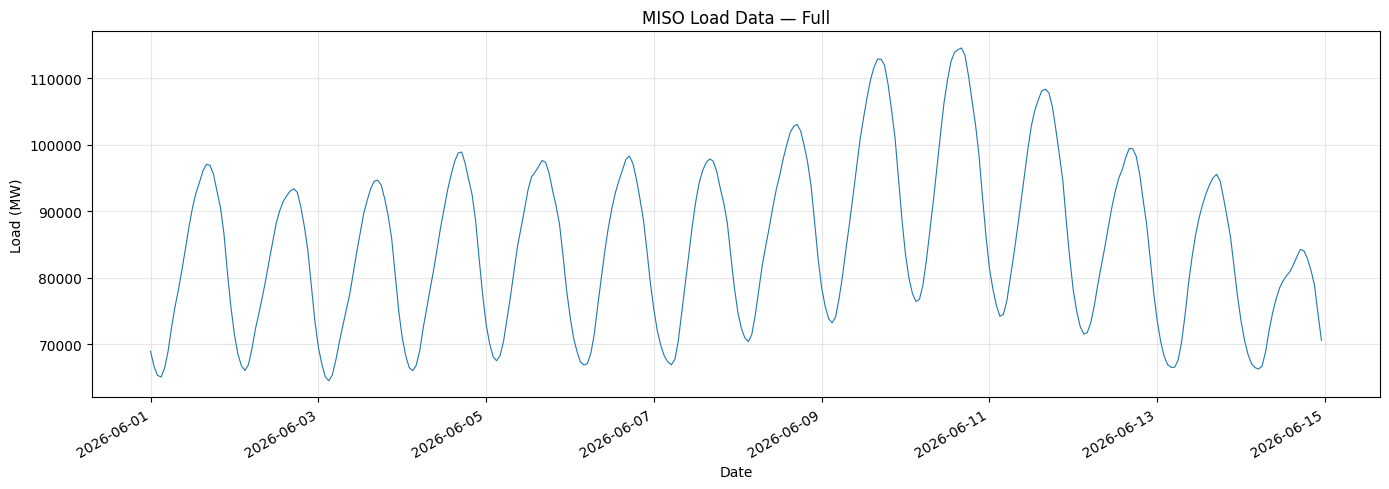

In [5]:
# Plot the full load history
fig, ax = plt.subplots()
ax.plot(df.index, df["load_mw"], linewidth=0.8)
ax.set_title("MISO Load Data — Full")
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
fig.autofmt_xdate()  # rotate date labels so they don't overlap
plt.tight_layout()
plt.show()

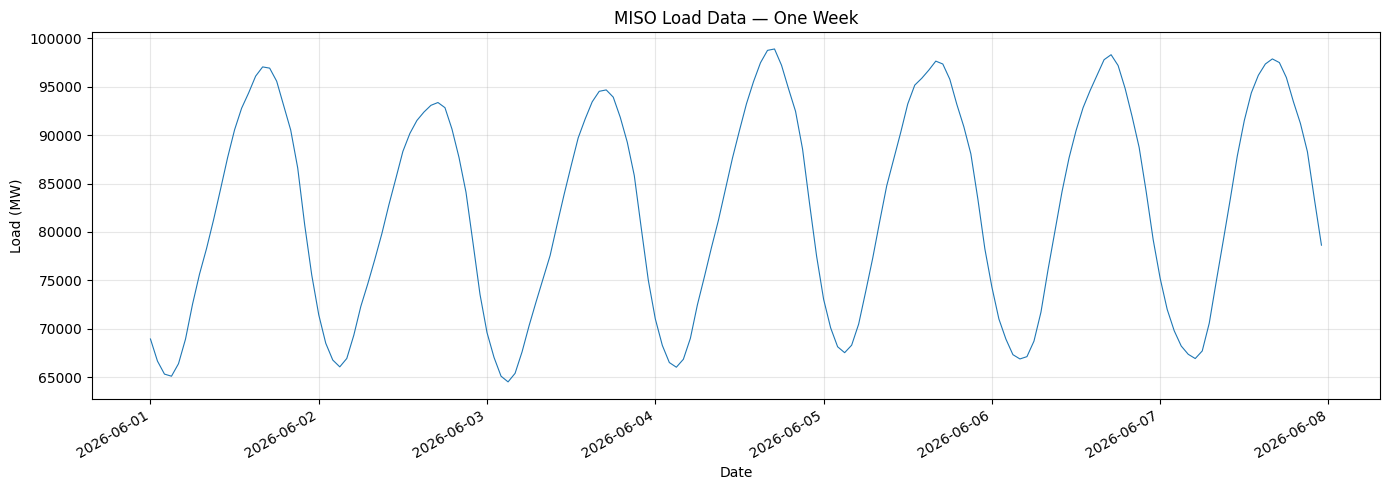

In [ ]:
# Plot a single week's history (first 168 hours of load data)
filtered_df = filter_by_date(df, datetime.datetime(2026, 6, 1, 0), datetime.datetime(2026, 6, 7, 23))

fig, ax = plt.subplots()
ax.plot(filtered_df.index, filtered_df["load_mw"], linewidth=0.8)
ax.set_title("MISO Load Data — One Week")
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

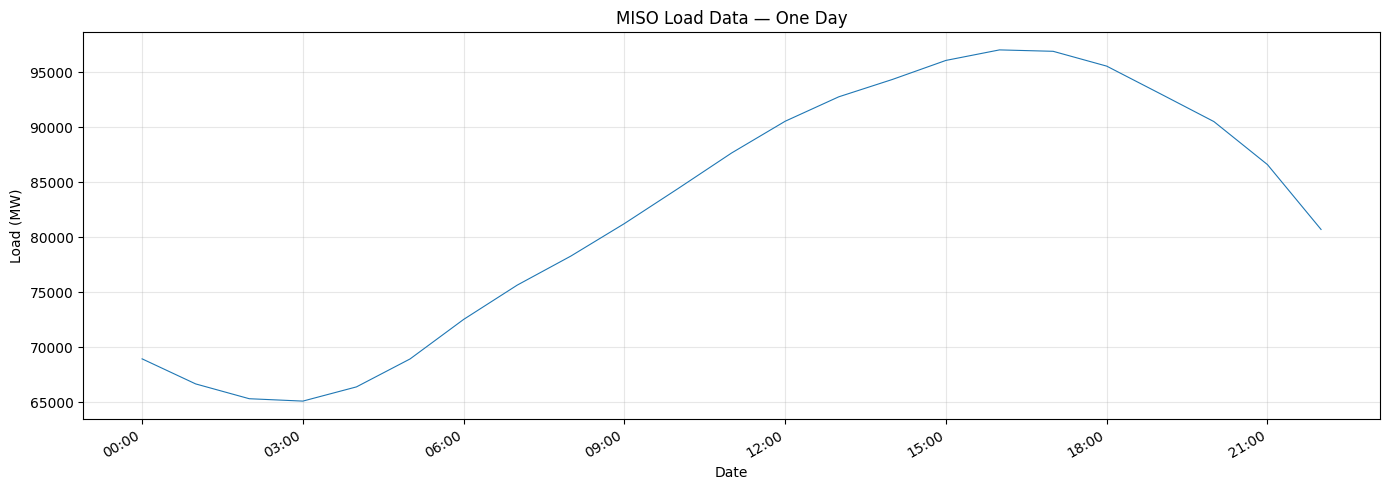

In [ ]:
# Plot a single day's history (first 24 hours of load data)
filtered_df = filter_by_date(df, datetime.datetime(2026, 6, 1, 0), datetime.datetime(2026, 6, 1, 23))
fig, ax = plt.subplots()
ax.plot(df.iloc[0:23].index, df.iloc[0:23]["load_mw"], linewidth=0.8)
ax.set_title("MISO Load Data — One Day")
ax.set_xlabel("Time")
ax.set_ylabel("Load (MW)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

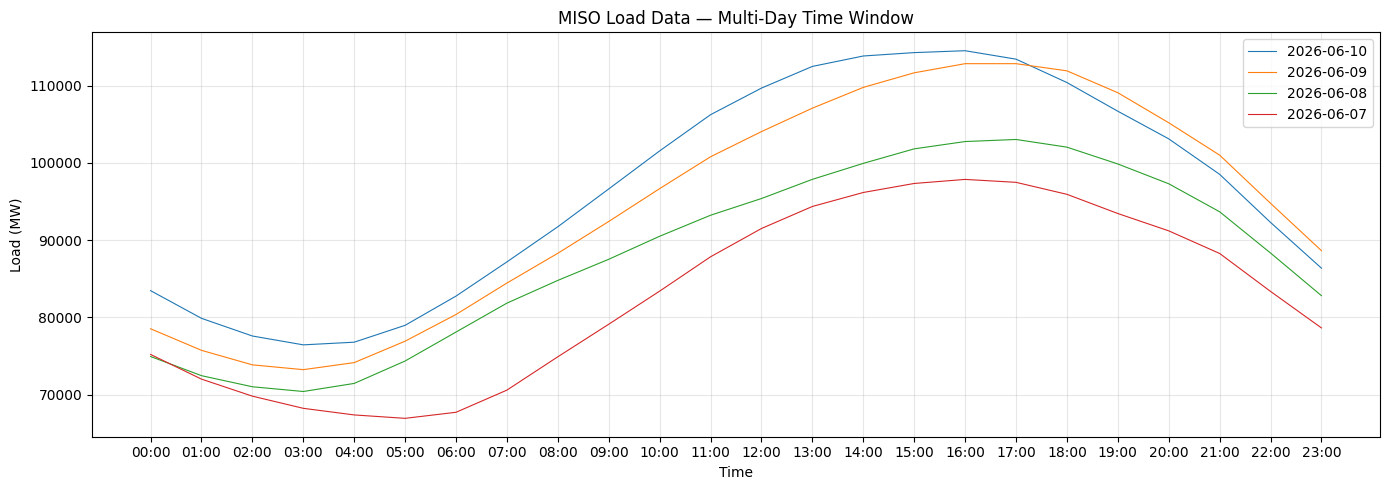

In [11]:
# Plot multi-day history from a specific 24h timeframe
start = datetime.datetime(2026, 6, 10, 0)
end = datetime.datetime(2026, 6, 10, 23)
lags = [0, 24, 48, 72]
filtered_dfs = []

for lag in lags:
    lagged_start = start - datetime.timedelta(hours=lag)
    lagged_end = end - datetime.timedelta(hours=lag)
    filtered_df = filter_by_date(df, lagged_start, lagged_end)
    filtered_dfs.append(filtered_df)

fig, ax = plt.subplots()

for filtered_df in filtered_dfs:
    ax.plot(pd.to_datetime(filtered_df.index).strftime("%H:%M"), filtered_df["load_mw"], linewidth=0.8, label=filtered_df.iloc[0]["date"])

ax.set_title("MISO Load Data — Multi-Day Time Window")
ax.set_xlabel("Time")
ax.set_ylabel("Load (MW)")
plt.tight_layout()
plt.legend()
plt.show()